# TWAS of Atopic Dermatitis — 8-Cohort Cross-Dataset Analysis

Integrates S-MultiXcan + S-PrediXcan results across all **8 Atopic Dermatitis GWAS** processed through the pipeline.

| OpenGWAS ID | Population | Sample Size | Author/Year |
|---|---|---|---|
| bbj-a-90 | East Asian | 212,036 | Ishigaki 2019 |
| ebi-a-GCST90018564 | East Asian | 168,103 | Sakaue 2021 |
| ebi-a-GCST90018784 | European | 481,299 | Sakaue 2021 |
| ebi-a-GCST90027161 | European | 796,661 | Sliz 2021 |
| finn-b-ATOPIC_STRICT | European | — | FinnGen 2021 |
| finn-b-ATOPIC_STRICT_REIMB | European | — | FinnGen 2021 |
| finn-b-L12_ATOPIC | European | — | FinnGen 2021 |
| ieu-b-5145 | Aboriginal Australian | 864,982 | Budu-Aggrey 2023 |

### Goals
1. **Per-cohort summary** — significant gene counts, top hits.
2. **Replication** — which genes are significant across multiple cohorts.
3. **Population stratification** — compare East Asian vs European signal.
4. **Meta-analysis** — Stouffer's Z across cohorts to find consensus genes.
5. **Top-gene z-score heatmap** — visualize direction/magnitude across cohorts and tissues.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (14, 6), 'figure.dpi': 120, 'font.size': 11,
    'axes.titlesize': 14, 'axes.labelsize': 12,
    'legend.fontsize': 10, 'figure.facecolor': 'white',
})

REPO_ROOT = Path('..').resolve()
DATA_DIR = REPO_ROOT / 'gwas-twas-analysis' / 'data'
SMULTIXCAN_DIR = DATA_DIR / 'output'
SPREDIXCAN_DIR = DATA_DIR / 'spredixcan'

# Cohort metadata (ordered for display)
COHORTS = [
    ('bbj-a-90',                'East Asian',             212036, 'Ishigaki 2019'),
    ('ebi-a-GCST90018564',      'East Asian',             168103, 'Sakaue 2021'),
    ('ebi-a-GCST90018784',      'European',               481299, 'Sakaue 2021'),
    ('ebi-a-GCST90027161',      'European',               796661, 'Sliz 2021'),
    ('finn-b-ATOPIC_STRICT',    'European',               np.nan, 'FinnGen 2021'),
    ('finn-b-ATOPIC_STRICT_REIMB','European',             np.nan, 'FinnGen 2021'),
    ('finn-b-L12_ATOPIC',       'European',               np.nan, 'FinnGen 2021'),
    ('ieu-b-5145',              'Aboriginal Australian',  864982, 'Budu-Aggrey 2023'),
]
meta = pd.DataFrame(COHORTS, columns=['cohort','population','n','author_year']).set_index('cohort')

POP_COLOR = {'East Asian': '#d73027', 'European': '#2166ac', 'Aboriginal Australian': '#fdae61'}
meta['color'] = meta['population'].map(POP_COLOR)
meta

,population,n,author_year,color
cohort,,,,
bbj-a-90,East Asian,212036.0,Ishigaki 2019,#d73027
ebi-a-GCST90018564,East Asian,168103.0,Sakaue 2021,#d73027
ebi-a-GCST90018784,European,481299.0,Sakaue 2021,#2166ac
ebi-a-GCST90027161,European,796661.0,Sliz 2021,#2166ac
finn-b-ATOPIC_STRICT,European,NaN,FinnGen 2021,#2166ac
finn-b-ATOPIC_STRICT_REIMB,European,NaN,FinnGen 2021,#2166ac
finn-b-L12_ATOPIC,European,NaN,FinnGen 2021,#2166ac
ieu-b-5145,Aboriginal Australian,864982.0,Budu-Aggrey 2023,#fdae61


## Load S-MultiXcan results for all 8 cohorts

In [2]:
smx = {}  # cohort -> DataFrame of valid genes
for c in meta.index:
    p = SMULTIXCAN_DIR / f'smultixcan_{c}.csv'
    df = pd.read_csv(p, sep='\t')
    df = df[df['status'] == 0].copy()
    df['logp'] = -np.log10(df['pvalue'].clip(lower=1e-300))
    smx[c] = df
    print(f'  {c:<30s} {len(df):>6,d} valid genes | min p = {df["pvalue"].min():.2e}')

# Summary table
summary = pd.DataFrame({
    'n_genes':      {c: len(smx[c]) for c in smx},
    'n_GWS_5e-8':   {c: (smx[c]['pvalue'] < 5e-8).sum()      for c in smx},
    'n_bonferroni': {c: (smx[c]['pvalue'] < 0.05/len(smx[c])).sum() for c in smx},
    'n_suggestive': {c: (smx[c]['pvalue'] < 1e-5).sum()      for c in smx},
    'top_gene':     {c: smx[c].nsmallest(1,'pvalue')['gene_name'].iloc[0] for c in smx},
    'top_p':        {c: smx[c]['pvalue'].min()               for c in smx},
})
summary = summary.join(meta[['population','n','author_year']])
summary = summary[['population','n','author_year','n_genes','n_GWS_5e-8','n_bonferroni','n_suggestive','top_gene','top_p']]
summary

  bbj-a-90                       22,303 valid genes | min p = 1.48e-31
  ebi-a-GCST90018564             22,302 valid genes | min p = 3.31e-25
  ebi-a-GCST90018784             22,343 valid genes | min p = 1.23e-21
  ebi-a-GCST90027161             22,337 valid genes | min p = 5.27e-20
  finn-b-ATOPIC_STRICT           22,327 valid genes | min p = 6.28e-15
  finn-b-ATOPIC_STRICT_REIMB     22,327 valid genes | min p = 1.13e-13


  finn-b-L12_ATOPIC              22,327 valid genes | min p = 2.59e-14
  ieu-b-5145                     22,336 valid genes | min p = 2.94e-60


,population,n,author_year,n_genes,n_GWS_5e-8,n_bonferroni,n_suggestive,top_gene,top_p
bbj-a-90,East Asian,212036.0,Ishigaki 2019,22303,34,47,51,RNF5,1.481004e-31
ebi-a-GCST90018564,East Asian,168103.0,Sakaue 2021,22302,47,67,81,SLC9A4,3.313872e-25
ebi-a-GCST90018784,European,481299.0,Sakaue 2021,22343,38,54,69,SLC9A4,1.229910e-21
ebi-a-GCST90027161,European,796661.0,Sliz 2021,22337,40,68,88,SLC9A4,5.267930e-20
finn-b-ATOPIC_STRICT,European,NaN,FinnGen 2021,22327,21,38,45,TNFRSF6B,6.277710e-15
finn-b-ATOPIC_STRICT_REIMB,European,NaN,FinnGen 2021,22327,22,39,48,TNFRSF6B,1.131987e-13
finn-b-L12_ATOPIC,European,NaN,FinnGen 2021,22327,24,34,47,AP5B1,2.586901e-14
ieu-b-5145,Aboriginal Australian,864982.0,Budu-Aggrey 2023,22336,118,183,232,LINC00302,2.942525e-60


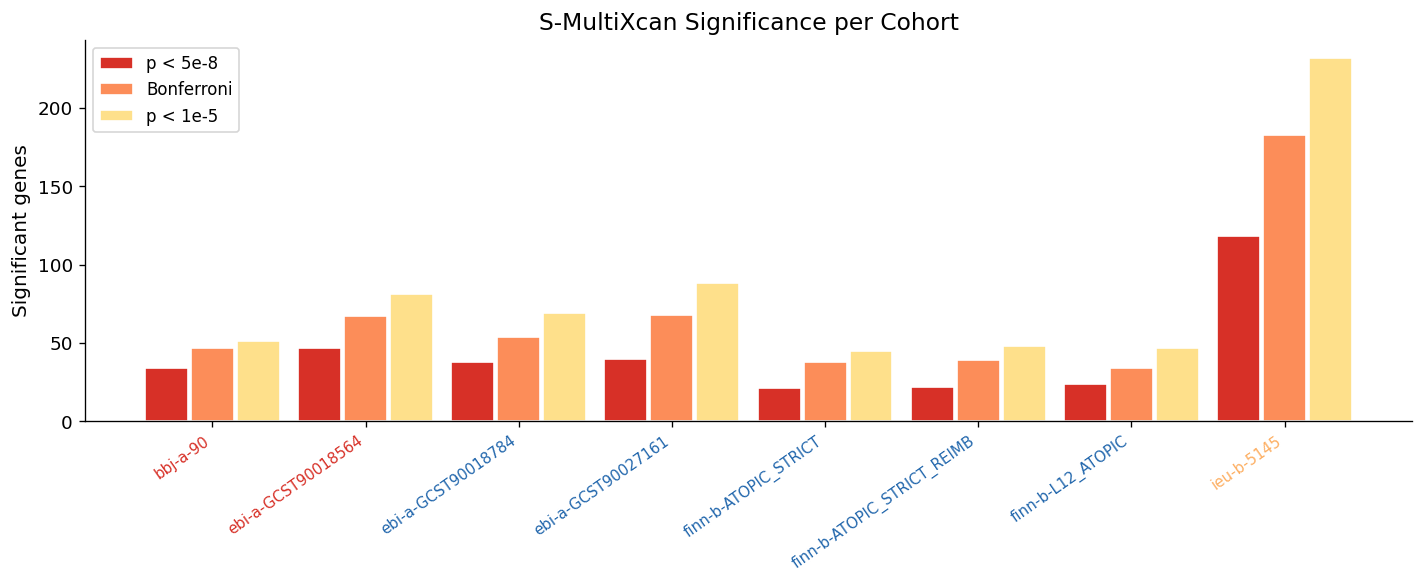

In [3]:
# Per-cohort significance bar chart
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(meta))
ax.bar(x - 0.3, summary['n_GWS_5e-8'],   width=0.28, color='#d73027', label='p < 5e-8', edgecolor='white')
ax.bar(x,       summary['n_bonferroni'], width=0.28, color='#fc8d59', label='Bonferroni', edgecolor='white')
ax.bar(x + 0.3, summary['n_suggestive'], width=0.28, color='#fee08b', label='p < 1e-5', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(meta.index, rotation=35, ha='right', fontsize=9)
for i, c in enumerate(meta.index):
    ax.get_xticklabels()[i].set_color(meta.loc[c, 'color'])
ax.set_ylabel('Significant genes')
ax.set_title('S-MultiXcan Significance per Cohort')
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## Replication across cohorts

How many cohorts is each gene genome-wide significant in? This separates cohort-specific hits from robust, population-replicated signal.

In [4]:
# Build per-cohort set of genome-wide-significant genes
gws_sets = {c: set(smx[c].loc[smx[c]['pvalue'] < 5e-8, 'gene_name']) for c in smx}

# Gene -> count of cohorts with p<5e-8
from collections import Counter
rep_count = Counter()
for s in gws_sets.values():
    rep_count.update(s)

rep = pd.DataFrame(rep_count.items(), columns=['gene','n_cohorts']).sort_values('n_cohorts', ascending=False)

print('Genes significant in N cohorts (p < 5e-8):')
print(rep['n_cohorts'].value_counts().sort_index(ascending=False).to_string())
print(f'\nUnion of all GWS genes: {len(rep)}  |  Any-cohort signal')
print(f'\nTop-replicated genes (p<5e-8 in ≥3 cohorts):')
rep[rep['n_cohorts'] >= 3].head(30)

Genes significant in N cohorts (p < 5e-8):
n_cohorts
8     2
7     5
6     8
5     8
4     6
3    15
2    26
1    84

Union of all GWS genes: 154  |  Any-cohort signal

Top-replicated genes (p<5e-8 in ≥3 cohorts):


,gene,n_cohorts
0,IL18RAP,8
27,OVOL1,8
40,LIME1,7
35,STMN3,7
38,TNFRSF6B,7
39,ARFRP1,7
16,IL18R1,7
50,RTEL1,6
51,LINC00302,6
2,MFSD9,6


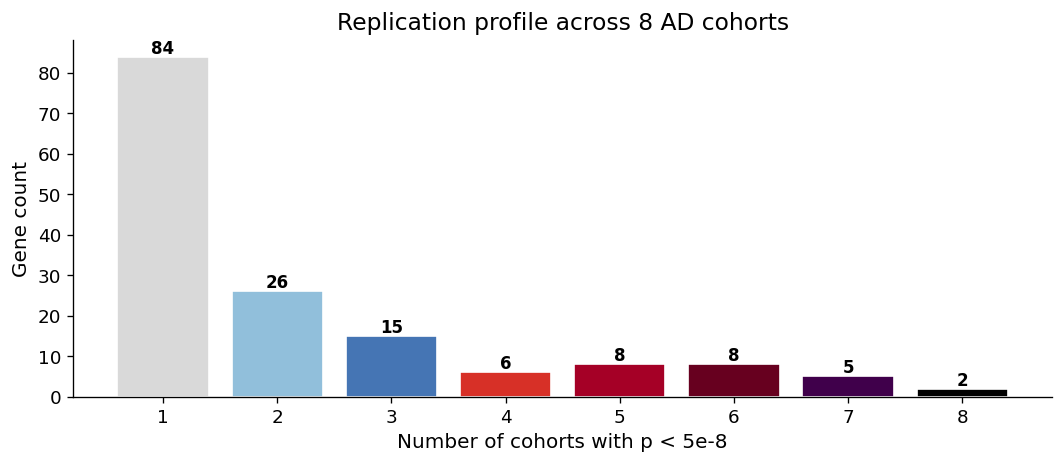

In [5]:
# Replication histogram
fig, ax = plt.subplots(figsize=(9, 4))
rep_hist = rep['n_cohorts'].value_counts().sort_index()
ax.bar(rep_hist.index, rep_hist.values,
       color=['#d9d9d9','#91bfdb','#4575b4','#d73027','#a50026','#67001f','#40004b','#000000'][:len(rep_hist)],
       edgecolor='white')
for i, (n, c) in enumerate(rep_hist.items()):
    ax.text(n, c + max(rep_hist.values)*0.01, str(c), ha='center', fontweight='bold', fontsize=10)
ax.set_xlabel('Number of cohorts with p < 5e-8')
ax.set_ylabel('Gene count')
ax.set_title('Replication profile across 8 AD cohorts')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## Top-gene z-score heatmap across cohorts

For each top gene (by meta-p across cohorts), show the S-MultiXcan `z_mean` (z-score averaged across tissues) per cohort. Red = positive direction, blue = negative; color intensity ~ effect magnitude.

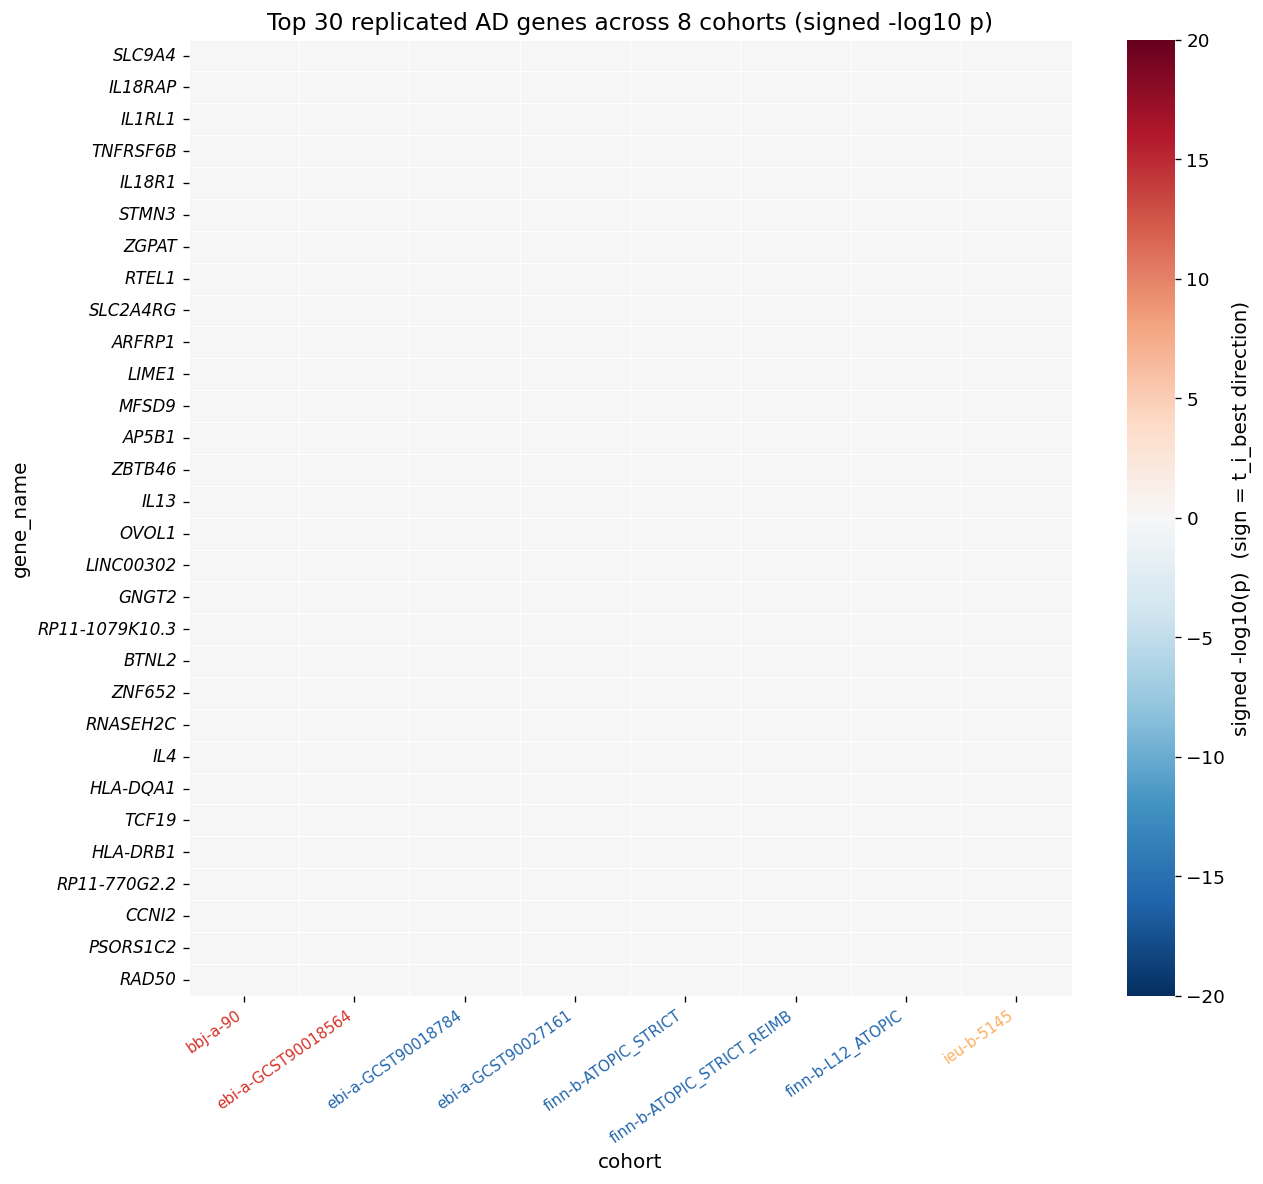

In [6]:
# Build a long dataframe of (gene, cohort) -> pvalue, z
# S-MultiXcan does not emit a single z per gene; use `t_i_best` (best-tissue t-stat as a directional proxy).
# Fallback: sign of best-tissue S-PrediXcan z for that gene.
frames = []
for c, df in smx.items():
    sub = df[['gene_name','pvalue']].copy()
    # t_i_best lives in df
    if 't_i_best' in df.columns:
        sub['t_i_best'] = pd.to_numeric(df['t_i_best'], errors='coerce')
    else:
        sub['t_i_best'] = np.nan
    sub['logp_signed'] = -np.log10(sub['pvalue'].clip(lower=1e-300)) * np.sign(sub['t_i_best'].fillna(0))
    sub['cohort'] = c
    frames.append(sub)
long = pd.concat(frames, ignore_index=True)

# Pick top genes by median -log10p across cohorts, requiring presence in ≥4 cohorts
presence = long.groupby('gene_name')['cohort'].nunique()
robust_genes = presence[presence >= 4].index
rank = long[long['gene_name'].isin(robust_genes)].groupby('gene_name')['pvalue'].apply(
    lambda s: np.median(-np.log10(s.clip(lower=1e-300)))
).sort_values(ascending=False)
TOP_N = 30
top_genes = rank.head(TOP_N).index.tolist()

pivot = long.pivot_table(index='gene_name', columns='cohort', values='logp_signed', aggfunc='first').reindex(top_genes)
pivot = pivot[meta.index.tolist()]

fig, ax = plt.subplots(figsize=(11, 10))
sns.heatmap(pivot, cmap='RdBu_r', center=0, vmin=-20, vmax=20,
            cbar_kws={'label':'signed -log10(p)  (sign = t_i_best direction)'},
            linewidths=0.3, linecolor='white', ax=ax)
ax.set_xticklabels([c for c in meta.index], rotation=35, ha='right', fontsize=9)
for t, c in zip(ax.get_xticklabels(), meta.index):
    t.set_color(meta.loc[c, 'color'])
ax.set_yticklabels(ax.get_yticklabels(), fontstyle='italic', fontsize=10)
ax.set_title(f'Top {TOP_N} replicated AD genes across 8 cohorts (signed -log10 p)')
plt.tight_layout(); plt.show()


## Population-stratified comparison

Compare significant-gene sets between East Asian and European cohorts.

East Asian (n=2): 49 GWS genes
European   (n=5): 60 GWS genes
Other      (n=1): 118 GWS genes

EA ∩ EU: 28 shared genes
EA only : 17
EU only : 6
All 3   : 15


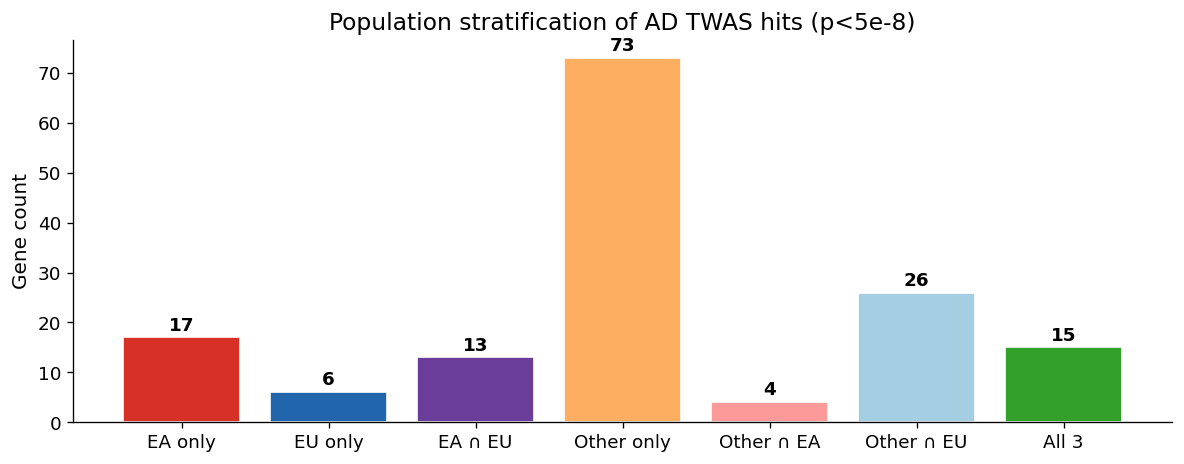

In [7]:
EA = meta[meta['population'] == 'East Asian'].index.tolist()
EU = meta[meta['population'] == 'European'].index.tolist()
OT = meta[~meta['population'].isin(['East Asian','European'])].index.tolist()

def union_sig(cohorts, thresh=5e-8):
    s = set()
    for c in cohorts:
        s.update(smx[c].loc[smx[c]['pvalue'] < thresh, 'gene_name'])
    return s

ea_genes = union_sig(EA)
eu_genes = union_sig(EU)
ot_genes = union_sig(OT) if OT else set()

print(f'East Asian (n={len(EA)}): {len(ea_genes)} GWS genes')
print(f'European   (n={len(EU)}): {len(eu_genes)} GWS genes')
print(f'Other      (n={len(OT)}): {len(ot_genes)} GWS genes')
print(f'\nEA ∩ EU: {len(ea_genes & eu_genes)} shared genes')
print(f'EA only : {len(ea_genes - eu_genes - ot_genes)}')
print(f'EU only : {len(eu_genes - ea_genes - ot_genes)}')
print(f'All 3   : {len(ea_genes & eu_genes & ot_genes) if ot_genes else "n/a"}')

# Venn-like bar chart of set sizes
labels = ['EA only', 'EU only', 'EA ∩ EU', 'Other only', 'Other ∩ EA', 'Other ∩ EU', 'All 3']
vals = [
    len(ea_genes - eu_genes - ot_genes),
    len(eu_genes - ea_genes - ot_genes),
    len((ea_genes & eu_genes) - ot_genes),
    len(ot_genes - ea_genes - eu_genes),
    len((ot_genes & ea_genes) - eu_genes),
    len((ot_genes & eu_genes) - ea_genes),
    len(ea_genes & eu_genes & ot_genes),
]
fig, ax = plt.subplots(figsize=(10,4))
ax.bar(labels, vals, color=['#d73027','#2166ac','#6a3d9a','#fdae61','#fb9a99','#a6cee3','#33a02c'], edgecolor='white')
for i, v in enumerate(vals):
    if v > 0:
        ax.text(i, v + max(vals)*0.02, str(v), ha='center', fontweight='bold')
ax.set_ylabel('Gene count'); ax.set_title('Population stratification of AD TWAS hits (p<5e-8)')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## Meta-analysis across cohorts (Stouffer's method)

Combine per-cohort S-MultiXcan p-values into a single consensus p per gene. Stouffer's method:

$$Z_{\text{meta}} = \frac{\sum_i w_i \, z_i}{\sqrt{\sum_i w_i^2}}$$

with weights $w_i = \sqrt{n_i}$ (sample size). Genes missing in a cohort are excluded from that term. Only genes present in ≥4 cohorts are meta-analyzed to protect against single-cohort-driven hits.

In [8]:
# For each cohort, build a gene -> (signed_z, weight) mapping.
# Sign comes from t_i_best; magnitude from S-MultiXcan z-score derived from p via two-sided inversion.
# S-MultiXcan is a chi-squared test (no natural sign), so we use |z| = sqrt(chi2) and apply t_i_best sign.

gene_to_data = {}  # gene -> list of (z, w, cohort)
for c, df in smx.items():
    n = meta.loc[c, 'n']
    w = np.sqrt(n if not np.isnan(n) else 150_000)  # fallback for missing n
    sign = np.sign(pd.to_numeric(df.get('t_i_best', pd.Series(1, index=df.index)), errors='coerce').fillna(0))
    sign = sign.replace(0, 1)
    chi2 = stats.chi2.isf(df['pvalue'].clip(lower=1e-300), df=1)
    z = sign * np.sqrt(chi2)
    for g, zi in zip(df['gene_name'], z):
        gene_to_data.setdefault(g, []).append((zi, w))

rows = []
for g, data in gene_to_data.items():
    if len(data) < 4:
        continue
    zs = np.array([d[0] for d in data])
    ws = np.array([d[1] for d in data])
    z_meta = (ws * zs).sum() / np.sqrt((ws**2).sum())
    p_meta = 2 * stats.norm.sf(abs(z_meta))
    rows.append((g, len(data), z_meta, p_meta))
meta_df = pd.DataFrame(rows, columns=['gene','n_cohorts','z_meta','p_meta']).sort_values('p_meta')
meta_df['logp'] = -np.log10(meta_df['p_meta'].clip(lower=1e-300))

bonf = 0.05 / len(meta_df)
print(f'Meta-analyzed genes (present in ≥4 cohorts): {len(meta_df):,}')
print(f'Genome-wide significant (p_meta < 5e-8):      {(meta_df["p_meta"] < 5e-8).sum():,}')
print(f'Bonferroni (p_meta < {bonf:.1e}):             {(meta_df["p_meta"] < bonf).sum():,}')
print(f'\nTop 25 meta-analysis hits:')
meta_df.head(25).reset_index(drop=True)


Meta-analyzed genes (present in ≥4 cohorts): 22,336
Genome-wide significant (p_meta < 5e-8):      563
Bonferroni (p_meta < 2.2e-06):             968

Top 25 meta-analysis hits:


,gene,n_cohorts,z_meta,p_meta,logp
0,SLC9A4,8,24.248102,6.924149e-130,129.159634
1,IL18RAP,8,22.777944,7.586841e-115,114.119939
2,IL18R1,8,21.470265,2.953275e-102,101.529696
3,MFSD9,8,21.130443,4.176128e-99,98.379226
4,IL1RL1,8,20.919286,3.574218e-97,96.446819
5,TNFRSF6B,8,20.794998,4.803774e-96,95.318417
6,ZGPAT,8,20.241293,4.239011e-91,90.372735
7,IL13,8,19.965817,1.092272e-88,87.961669
8,ARFRP1,8,19.842532,1.278532e-87,86.893288
9,LINC00302,8,19.741705,9.453346e-87,86.024414


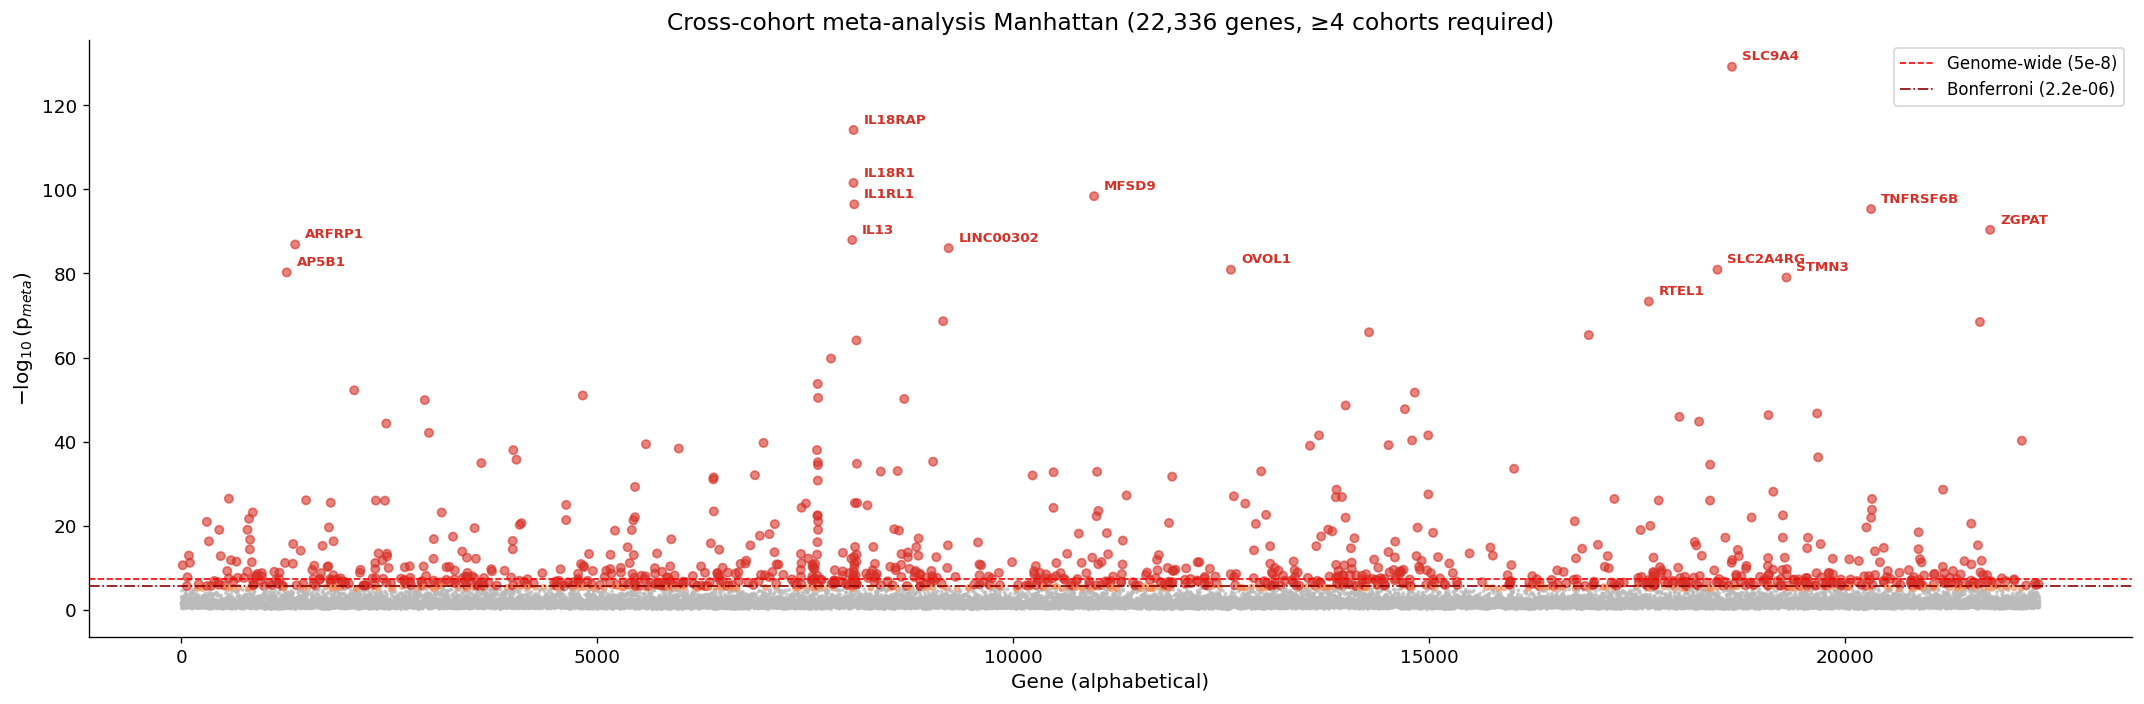

In [9]:
# Meta-analysis Manhattan (x = rank, labeled top hits)
md = meta_df.sort_values('gene').reset_index(drop=True)
md['rank'] = np.arange(len(md))

fig, ax = plt.subplots(figsize=(18, 6))
colors = np.where(md['p_meta'] < bonf, '#d73027',
         np.where(md['p_meta'] < 1e-5, '#fc8d59', '#bababa'))
sizes = np.where(md['p_meta'] < bonf, 25, np.where(md['p_meta'] < 1e-5, 10, 2))
ax.scatter(md['rank'], md['logp'], c=colors, s=sizes, alpha=0.6, rasterized=True)
ax.axhline(-np.log10(5e-8), color='red', ls='--', lw=1, label='Genome-wide (5e-8)')
ax.axhline(-np.log10(bonf), color='darkred', ls='-.', lw=1, label=f'Bonferroni ({bonf:.1e})')
for _, r in md.nsmallest(15, 'p_meta').iterrows():
    ax.annotate(r['gene'], (r['rank'], r['logp']), fontsize=8, fontweight='bold', color='#d73027',
                xytext=(6,4), textcoords='offset points',
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.4))
ax.set_xlabel('Gene (alphabetical)'); ax.set_ylabel('$-\\log_{10}$(p$_{meta}$)')
ax.set_title(f'Cross-cohort meta-analysis Manhattan ({len(md):,} genes, ≥4 cohorts required)')
ax.legend(loc='upper right'); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## Top consensus hits: per-cohort p-value matrix

For the top 20 meta-analysis genes, show p-values from each cohort side-by-side. Reveals whether the consensus is broad (all cohorts contribute) or driven by one large-N study.

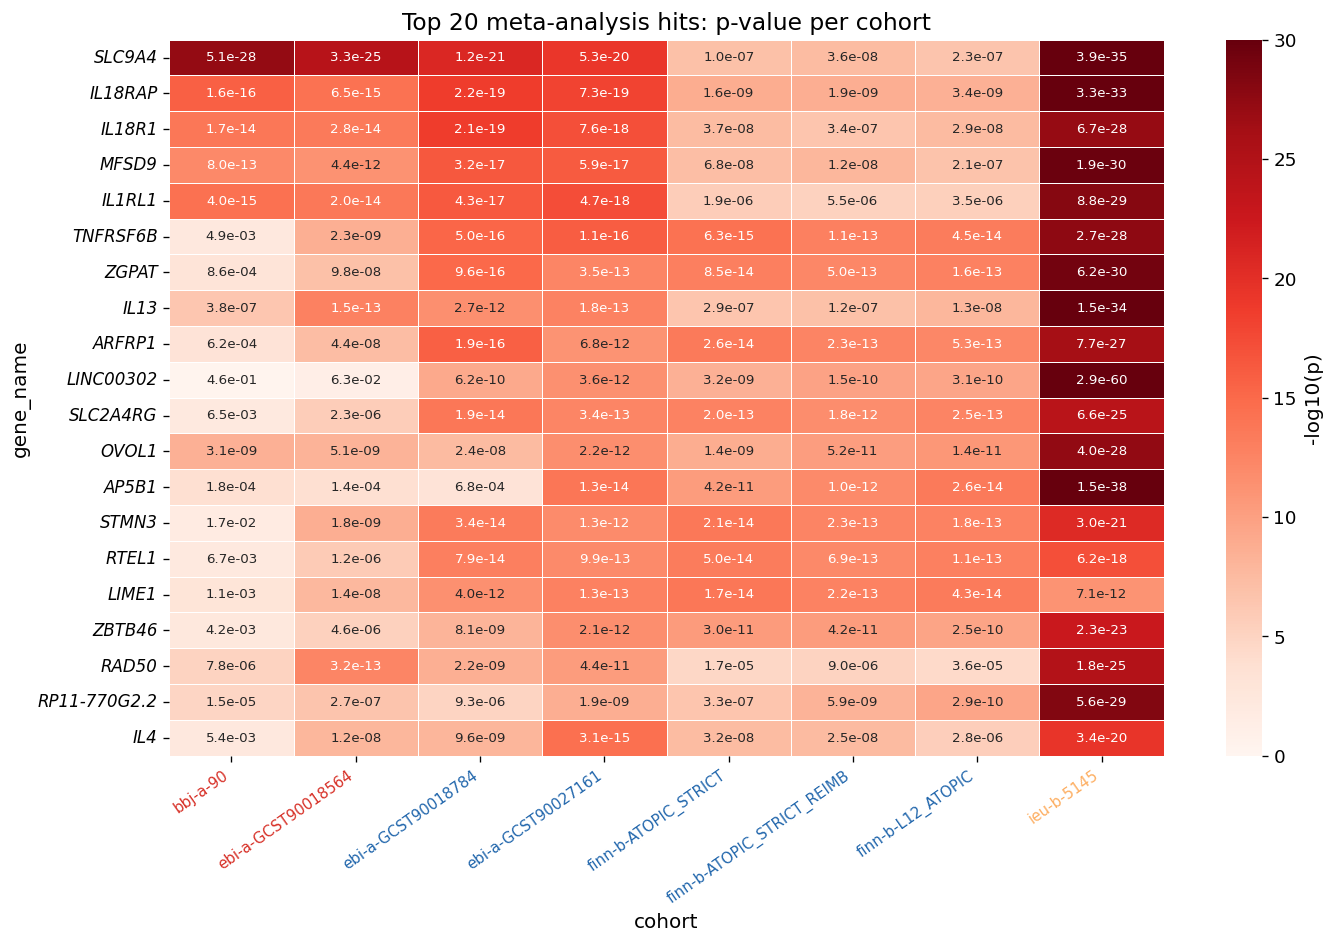

In [10]:
top_meta = meta_df.head(20)['gene'].tolist()
pmat = long.pivot_table(index='gene_name', columns='cohort', values='pvalue', aggfunc='first').reindex(top_meta)
pmat = pmat[meta.index.tolist()]

# Format for display: p-values in scientific, color by -log10p
logp_mat = -np.log10(pmat.clip(lower=1e-300))
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(logp_mat, annot=pmat.apply(lambda s: s.apply(lambda x: f'{x:.1e}' if pd.notna(x) else '')).values,
            fmt='', cmap='Reds', vmin=0, vmax=30,
            cbar_kws={'label':'-log10(p)'}, linewidths=0.3, linecolor='white', ax=ax,
            annot_kws={'fontsize':8})
ax.set_xticklabels([c for c in meta.index], rotation=35, ha='right', fontsize=9)
for t, c in zip(ax.get_xticklabels(), meta.index):
    t.set_color(meta.loc[c, 'color'])
ax.set_yticklabels(ax.get_yticklabels(), fontstyle='italic', fontsize=10)
ax.set_title('Top 20 meta-analysis hits: p-value per cohort')
plt.tight_layout(); plt.show()

## Tissue enrichment across cohorts

Using S-PrediXcan: which GTEx tissues consistently show the most significant genes across cohorts? A tissue relevant to AD biology (skin, immune) should rank high in most cohorts.

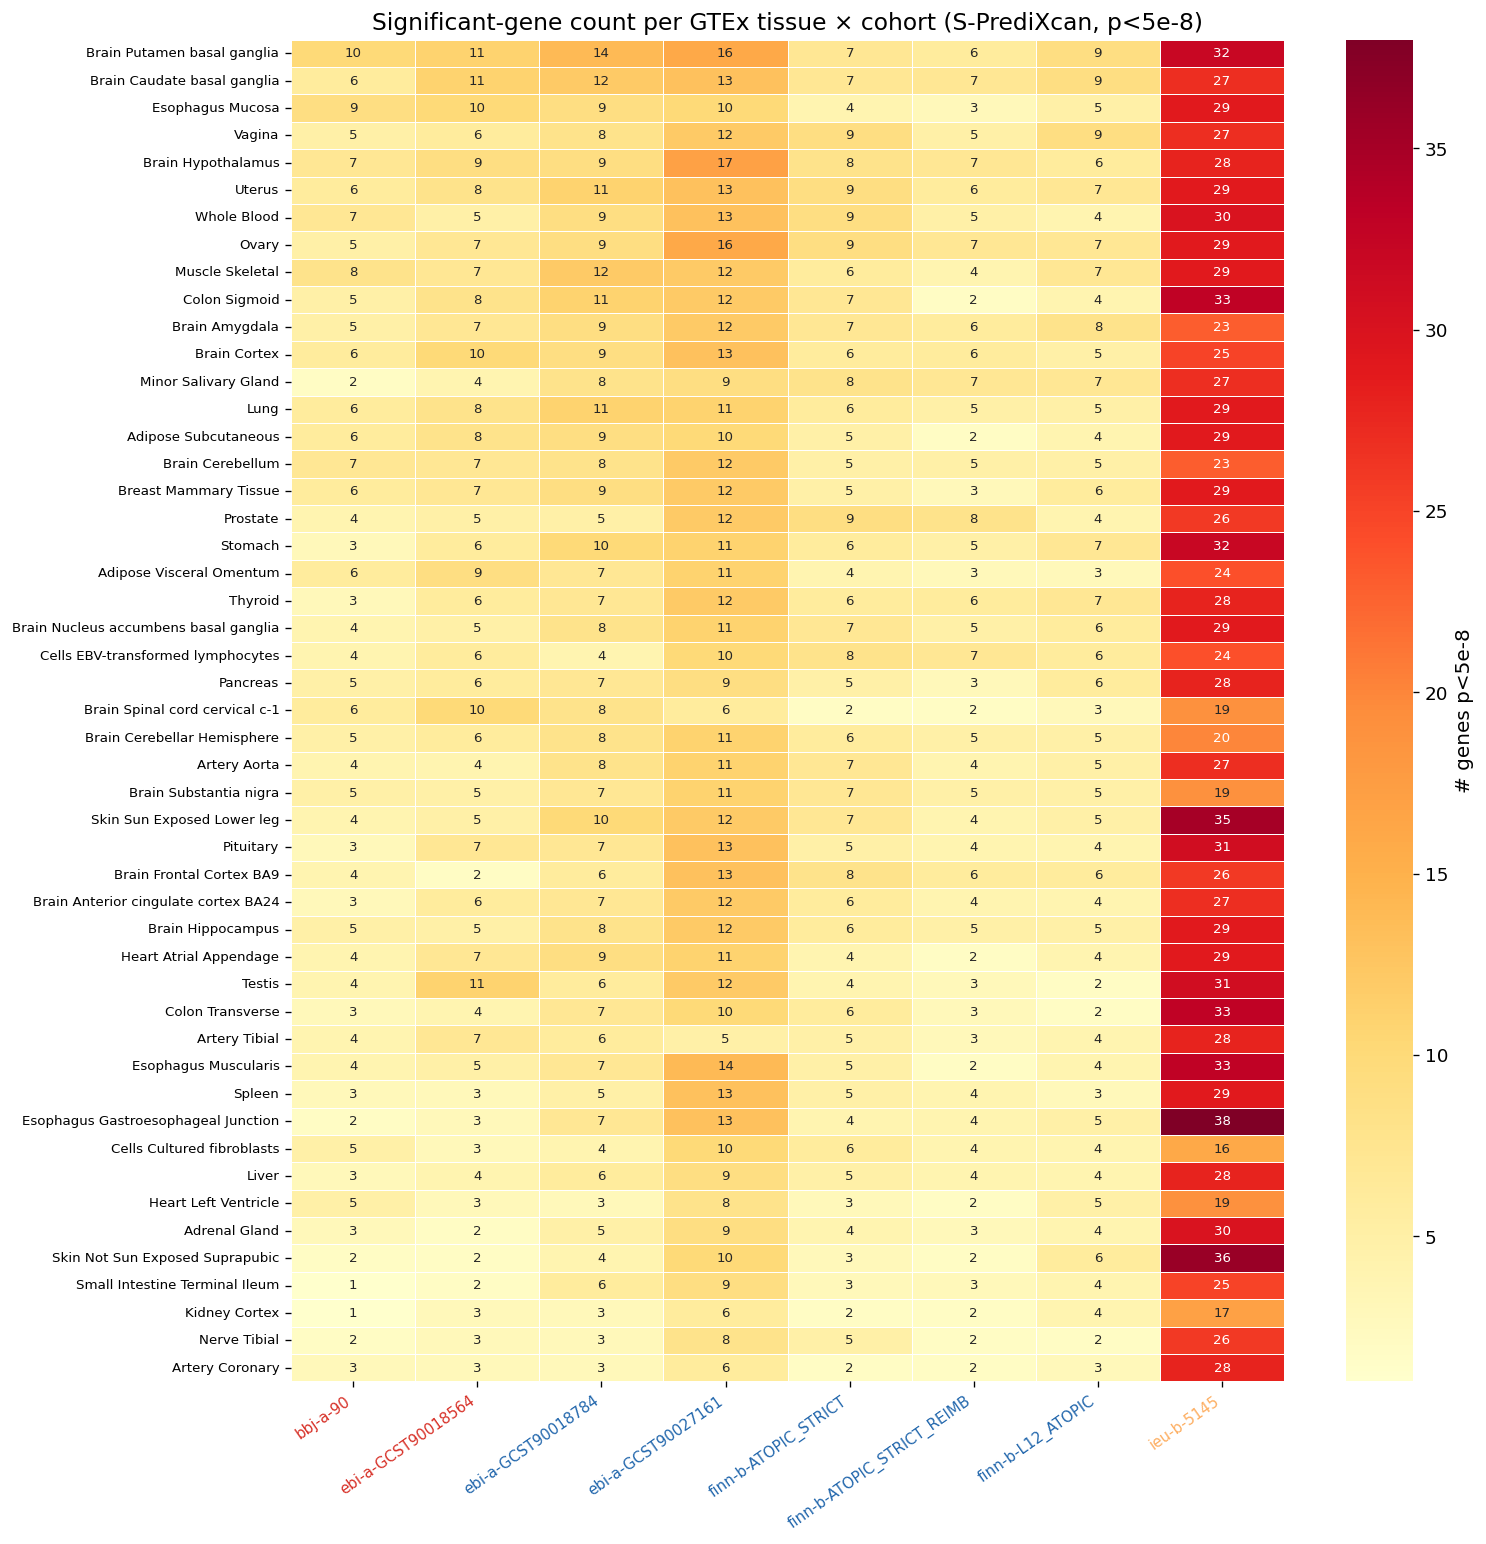

In [11]:
# Per cohort, count p<5e-8 genes in each of 49 tissues
def count_sig_by_tissue(cohort, thresh=5e-8):
    d = SPREDIXCAN_DIR / cohort
    out = {}
    for f in d.glob(f'spredixcan_{cohort}_*.csv'):
        tissue = f.stem.replace(f'spredixcan_{cohort}_', '')
        df = pd.read_csv(f, usecols=['pvalue'])
        out[tissue] = (df['pvalue'] < thresh).sum()
    return out

tissue_mat = pd.DataFrame({c: count_sig_by_tissue(c) for c in meta.index}).fillna(0).astype(int)
# Rank tissues by median sig-count across cohorts
tissue_mat['median_sig'] = tissue_mat.median(axis=1)
tissue_mat = tissue_mat.sort_values('median_sig', ascending=False).drop(columns='median_sig')

fig, ax = plt.subplots(figsize=(13, 13))
sns.heatmap(tissue_mat, cmap='YlOrRd', annot=True, fmt='d', cbar_kws={'label':'# genes p<5e-8'},
            linewidths=0.3, linecolor='white', ax=ax, annot_kws={'fontsize':8})
ax.set_xticklabels([c for c in tissue_mat.columns], rotation=35, ha='right', fontsize=9)
for t, c in zip(ax.get_xticklabels(), tissue_mat.columns):
    if c in meta.index:
        t.set_color(meta.loc[c, 'color'])
ax.set_yticklabels([t.replace('_',' ') for t in tissue_mat.index], fontsize=8)
ax.set_title('Significant-gene count per GTEx tissue × cohort (S-PrediXcan, p<5e-8)')
plt.tight_layout(); plt.show()

## Summary

- Per-cohort significance, population split (EA/EU/Other).
- Replicated genes across cohorts = robust AD TWAS signal.
- Stouffer's meta-analysis prioritizes consensus genes while down-weighting cohort-specific outliers.
- Top GTEx tissues by aggregate significance = candidate tissues of action for AD genetic risk.

**Next steps** (outside this notebook):
- Intersect top meta-analysis hits with known AD GWAS loci (FLG, filaggrin pathway, IL-4/13 axis) for validation.
- Run colocalization (coloc / fastENLOC) to distinguish causal from confounded TWAS hits.
- Query DrugBank / ChEMBL for compounds targeting the top consensus genes → drug repurposing candidates (the repo's end goal).